# Pr-YBCO version Fit modes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from importlib import reload
import C2_alris_one_third_functions as C2_alris_one_third_functions
reload(C2_alris_one_third_functions)
from C2_alris_one_third_functions import shift_atoms, transform_list_hkl_p63_p65, get_structure_factors , atom_position_list
from matplotlib.markers import MarkerStyle
from time import time

tf.keras.utils.set_random_seed(1)

Define the function containing the fitting parameters

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- `fun_tf()` correspond to the **structure factor calculation function** (one has to convert it to a **TF-compatible** function)
- <span style="color:red">If conversion to TF-compatible function is not possible, then this approach will probably not work (or becomes much more tedious at least)</span>

In [2]:
mode_num = 102
structure_type = 'C2'

path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type

# experimental_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no0.csv')
experimental_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no0.csv')

hkl_list = experimental_data[["h", "k", "l"]].values.tolist()
hkl_list = tf.convert_to_tensor(hkl_list, dtype=tf.float32)

path_matrix = path + '/C2_matrix.txt'
matrix = np.loadtxt(path_matrix, dtype=np.float32)
matrix = tf.convert_to_tensor(matrix, dtype=tf.float32)

Sample the "training data" (features and labels)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The features are the (h,k,l) coordinates (e.g. a vector of size `n_features` x 3, i.e. `n_dim = 3`)
- Maybe one has to normalize the features (i.e. not using integers but floats between -1 (0) and 1)? Before passing them to the structure calculation function, they should be again rescaled to integers
- The labels would be the experimental intensities (again, maybe have to be normalized to the range between 0 and 1)

Max label ERR: 30039.662
min label ERR: 0.14331529
Features shape: (371, 3)
Labels shape: (371, 1)
error shape: (371, 1)
Max label: 6.9776225
min label : 3.328932e-05


(array([0., 9., 3., 9., 3., 2., 3., 2., 4., 0., 1., 2., 1., 1., 1., 0., 1.,
        0., 0., 1., 0., 2., 0., 0., 2., 1., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.]),
 array([0.        , 0.14240046, 0.28480092, 0.42720138, 0.56960184,
        0.7120023 , 0.85440276, 0.99680322, 1.13920367, 1.28160413,
        1.42400459, 1.56640505, 1.70880551, 1.85120597, 1.99360643,
        2.13600689, 2.27840735, 2.42080781, 2.56320827, 2.70560873,
        2.84800919, 2.99040965, 3.13281011, 3.27521057, 3.41761102,
        3.56001148, 3.70241194, 3.8448124 , 3.98721286, 4.12961332,
        4.27201378, 4.41441424, 4.5568147 , 4.69921516, 4.84161562,
        4.98401608, 5.12641654, 5.268817  , 5.41121746, 5.55361792,
        5.69601837, 5.83841883, 5.98081929, 6.12321975, 6.26562021,
        6.40802067, 6.55042113, 6.69282159, 6.83522205, 6.97762251]),
 <BarContainer object of 49 artists>)

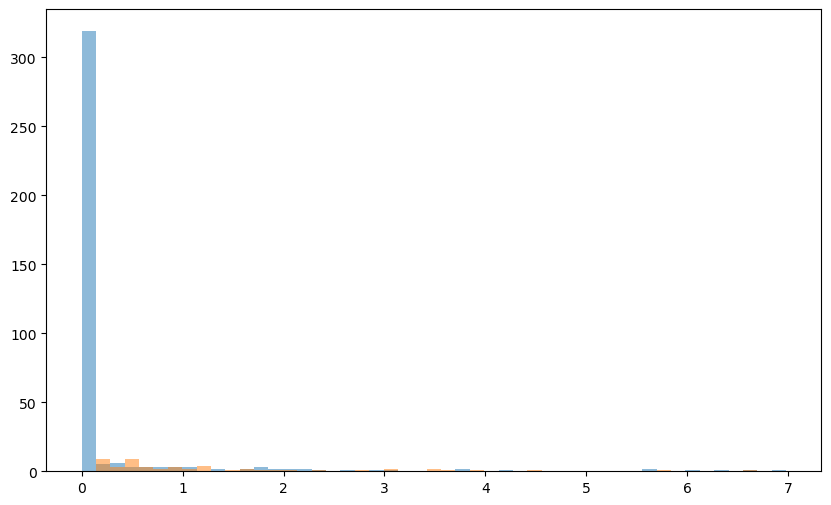

In [3]:
n_features = experimental_data.shape[0]
n_dim = 3

features = hkl_list
labels = experimental_data["intensity_exp"].tolist()
vol_err = experimental_data["intensity_exp_err"].tolist()


#labels = labels / np.max(labels) #Normalize labels
labels = labels / np.sum(labels) * 100  # Normalize to sum to 60

labels_err = []

for label, err in zip(labels, vol_err):
    if label == 0:
        labels_err.append(1e-9)  # Assign a high error for zero labels
    else:
        labels_err.append(1/label)
        # labels_err.append((label**3)  ) # Normalize error to sum to 60
        #labels_err.append(np.abs((5000 - (1/label * 100))))  # Inverse error for each label

labels_tgt = [labels, labels_err]
labels_tgt = np.transpose(labels_tgt)
labels_err = tf.convert_to_tensor(labels_err, dtype=tf.float32)
labels = tf.convert_to_tensor(labels, dtype=tf.float32)

labels = tf.expand_dims(labels, axis=-1)  # Ensure labels are 2D
labels_err = tf.expand_dims(labels_err, axis=-1)  # Ensure labels_err are 2D

print("Max label ERR:", np.max(labels_err))
print("min label ERR:", np.min(labels_err))
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print('error shape:', labels_err.shape)
print("Max label:", np.max(labels))
print("min label :", np.min(labels))
#bin from0 to 0.0025 with 50 bins
plt.figure(figsize=(10, 6))

plt.hist(labels.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels')
plt.hist(labels_err.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels Error')


In [4]:
def fun_tf(hkl_list, pars, matrix):
    """
    Fast computation of structure factors with parameter-dependent structure.
    """
    # stack parameters
    pars_tensor = tf.stack(pars)  # shape (params,)

    atom_shift_list = shift_atoms(matrix , (pars_tensor))
    atom_shift_list = atom_shift_list[:,0]
    atom_shift_list = tf.unstack(atom_shift_list)

    modified_struct = atom_position_list(*atom_shift_list)
    hkl_list = transform_list_hkl_p63_p65(hkl_list)

    # Get structure factors
    sf_hkl = get_structure_factors(hkl_list, modified_struct)
    intensity = (abs(sf_hkl)) ** 2

    w = tf.constant(0.000811509257682975, dtype=tf.float32)  # Debye-Waller factor 
    qnorms = tf.norm(tf.cast(hkl_list, tf.float32), axis=1)
    intensity = intensity * tf.exp(- w * qnorms ** 2)  # Apply Debye-Waller factor
    #intensity = log10(intensity + 1)  # Convert to log10 scale


    sim_intensity = intensity
    #sim_intensity = intensity / tf.reduce_max(intensity)  # Normalize to max intensity
    sim_intensity = sim_intensity / tf.reduce_sum(sim_intensity) * 100
    max_intensity = tf.reduce_max(sim_intensity)
    # sim_intensity = tf.where(sim_intensity < max_intensity * 0.0015, tf.zeros_like(sim_intensity), sim_intensity)  # Ensure no negative intensities

    return sim_intensity



In [5]:
best_model_pars = np.zeros(102, dtype=np.float32)  # Initialize with zeros
best_model_pars = tf.convert_to_tensor(best_model_pars, dtype=tf.float32)   
experimental_data['intensity_sim'] = fun_tf(features, best_model_pars , matrix).numpy()


In [6]:
def plot_plane_sim_vs_exp_DIM3(ax, df, r_factor, l, norm_plane=False):
    exp_data_0 = df.loc[df['l'] == l].copy()
    if norm_plane == True:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 100
    
    # ax.scatter(exp_data_0['h'], exp_data_0['k'], 
    #         s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
    #         label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    # ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['intensity_exp'] + 1)* 500 , color='blue', edgecolor="black",
    #         label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=exp_data_0['intensity_sim'] * 100, color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=exp_data_0['intensity_exp'] * 100, color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

def plot_plane_sim_vs_exp_DIM3_no_bragg(ax, df, r_factor, l, norm_plane=False):
    exp_data_0 = df.loc[df['l'] == l].copy()
    #copy the dataframe and remove rows where h and k are both integer
    exp_data_0 = exp_data_0[~((exp_data_0['h'] % 1 == 0) & (exp_data_0['k'] % 1 == 0))]
    if norm_plane == True:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 100

    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['intensity_exp'] + 1) * 500 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

def alris_r_factor(data):
    exp_intensity = data['intensity_exp'] / np.max(data['intensity_exp'])
    exp_intensity = exp_intensity / np.sum(exp_intensity) * 100
    simulated_intensity = data['intensity_sim']
    alris_r_factor = np.sum(np.abs(exp_intensity - simulated_intensity)) / np.sum(np.abs(exp_intensity))
    return alris_r_factor

ALRIS R-factor: 0.533


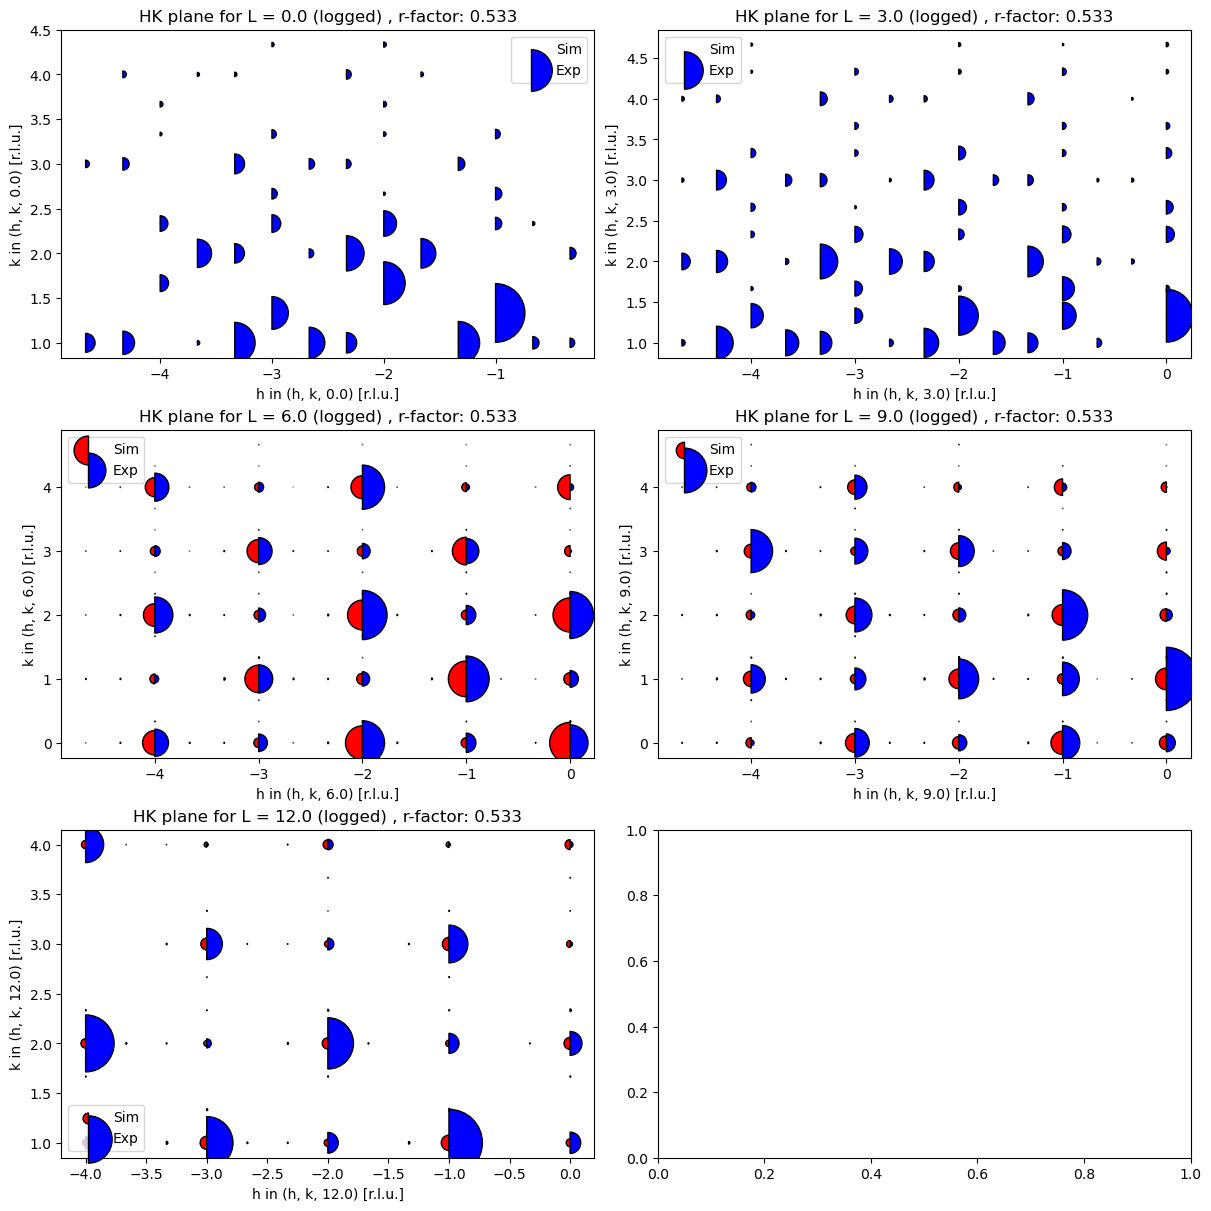

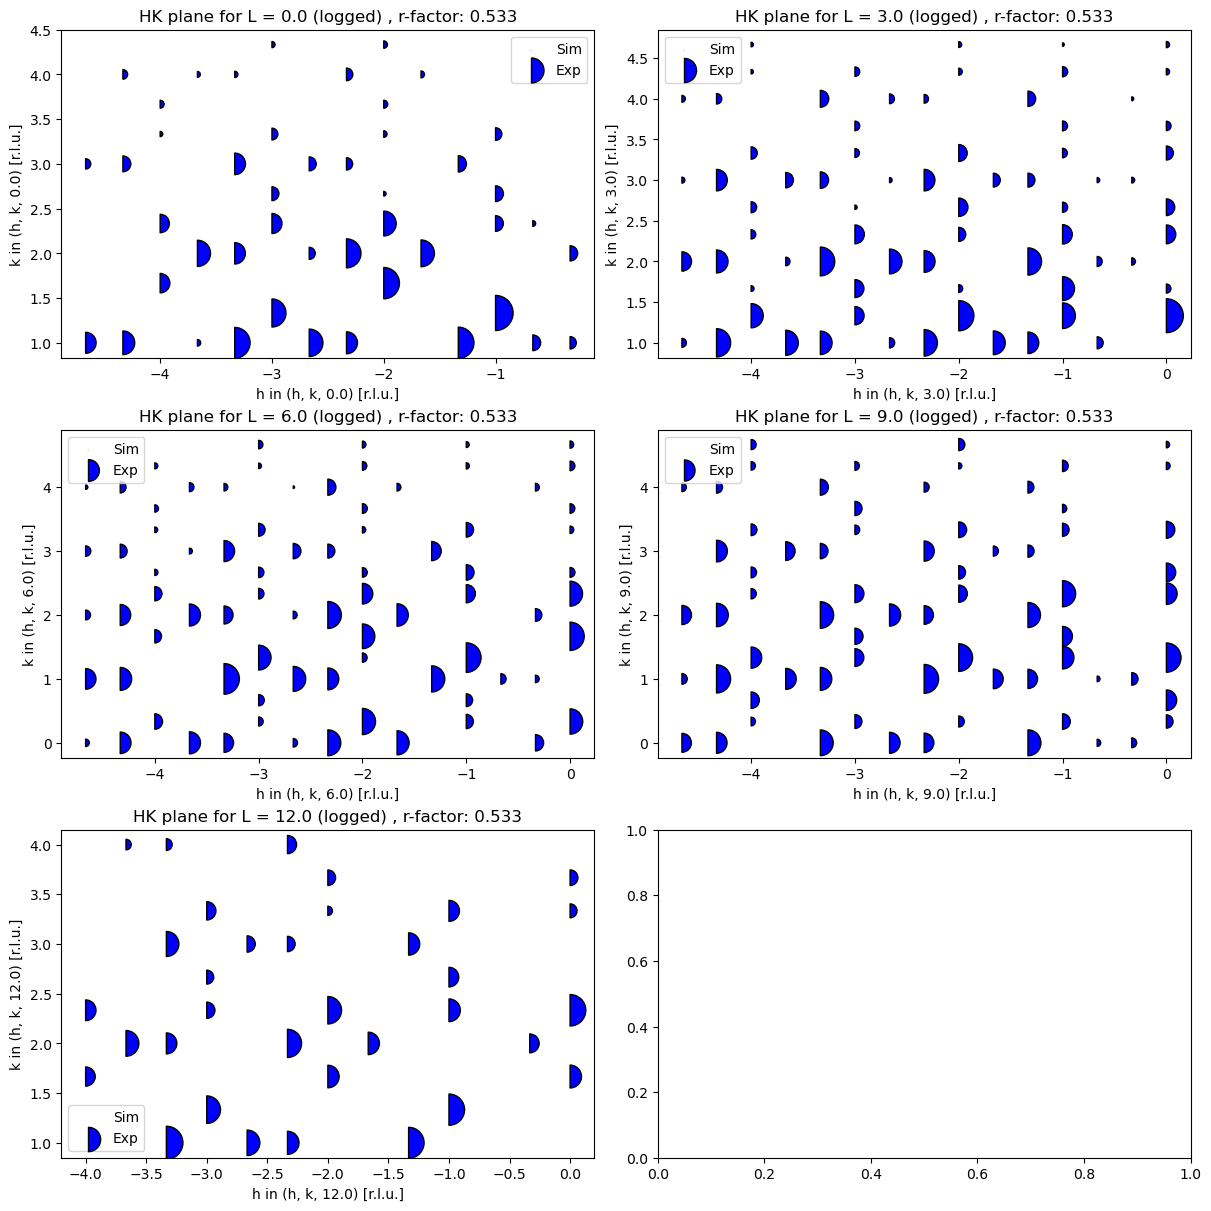

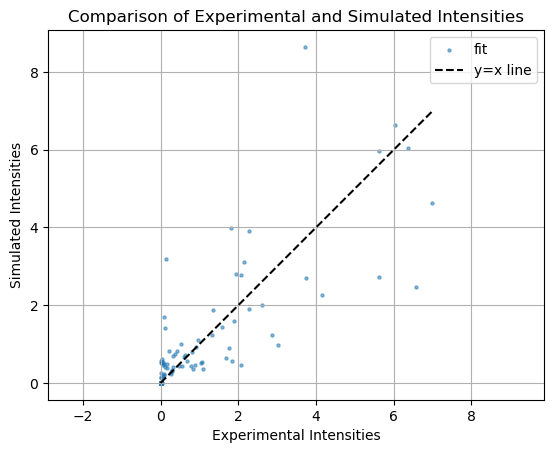

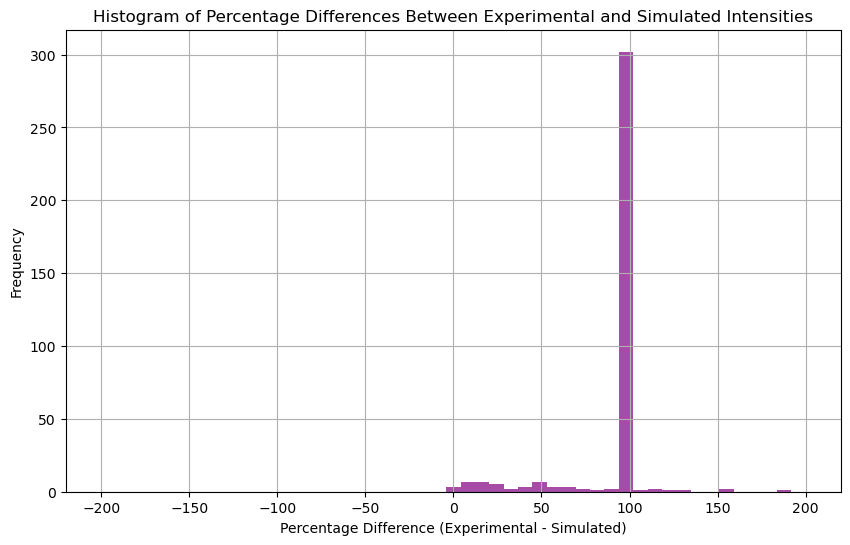

In [7]:
r_factor = alris_r_factor(experimental_data)
print(f"ALRIS R-factor: {r_factor:.3f}")

normalised_exp_data = experimental_data['intensity_exp'] / np.sum(experimental_data['intensity_exp']) * 100
experimental_data['normalised_intensity_exp'] = normalised_exp_data
experimental_data['intensity_exp_err'] = labels_err.numpy()

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], experimental_data, r_factor,l, norm_plane=True)

plt.show()

fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()
for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3_no_bragg(axs[i], experimental_data, r_factor,l, norm_plane=True)
plt.show()

normalised_exp = experimental_data['intensity_exp']/np.sum(experimental_data['intensity_exp']) * 100

x = np.linspace(0 ,max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, experimental_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - experimental_data['intensity_sim']) / normalised_exp * 100
experimental_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()